## Proyecto: Predicción de Riesgo Crediticio
### 1. Importación de librerías y configuración inicial

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys


### Cargar y Traducción del Set de Datos

In [66]:
column_names_raw = [
    'status_checking', 'duration_months', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_since', 'investment_rate',
    'status_sex', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits',
    'job', 'people_liable', 'telephone', 'foreign_worker', 'target'
]

raw_data_path = "../data/raw/german.data"

# Carga de los datos crudos separados por espacios en blanco
df = pd.read_csv(raw_data_path, sep=r'\s+', names=column_names_raw, header=None)

# Estandarizamos a formato binario tradicional: 0 = Buen Crédito (Confiable), 1 = Mal Crédito (Riesgo)
df['target'] = df['target'].map({1: 0, 2: 1})

# Diccionario corregido con las llaves exactas para traducir a español
nombres_espanol = {
    'status_checking': 'estado_cuenta',
    'duration_months': 'duracion_meses',
    'credit_history': 'historial_credito',
    'purpose': 'proposito',
    'credit_amount': 'monto_credito',
    'savings_account': 'estado_ahorros',
    'employment_since': 'empleo_anyos',
    'investment_rate': 'tasa_cuota',
    'status_sex': 'estado_personal',
    'other_debtors': 'otros_deudores',
    'residence_since': 'residencia_desde',
    'property': 'tipo_propiedad',
    'age': 'edad',
    'other_installments': 'otros_planes_pago',
    'housing': 'vivienda',
    'existing_credits': 'creditos_existentes',
    'job': 'tipo_empleo',
    'people_liable': 'num_dependientes',
    'telephone': 'telefono_propio',
    'foreign_worker': 'trabajador_extranjero',
    'target': 'clase'
}

# Renombrar columnas formalmente en el DataFrame
df.rename(columns=nombres_espanol, inplace=True)

print(f"Datos cargados y traducidos correctamente: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Datos cargados y traducidos correctamente: 1000 filas, 21 columnas


,estado_cuenta,duracion_meses,historial_credito,proposito,monto_credito,estado_ahorros,empleo_anyos,tasa_cuota,estado_personal,otros_deudores,...,tipo_propiedad,edad,otros_planes_pago,vivienda,creditos_existentes,tipo_empleo,num_dependientes,telefono_propio,trabajador_extranjero,clase
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


### Descripción de las variables del proyecto (Riesgo Crediticio)
Variables predictoras (20):
estado_cuenta (checking_status): Estado de la cuenta corriente.

A11: < 0 DM

A12: 0 ≤ ... < 200 DM

A13: ... ≥ 200 DM / salario por meses durante al menos 1 año

A14: sin cuenta corriente

duracion_meses (duration): Duración del crédito en meses.

historial_credito (credit_history): Historial crediticio.

A30: no hay créditos tomados / todos los créditos pagados debidamente

A31: todos los créditos en este banco pagados debidamente

A32: créditos existentes pagados debidamente hasta ahora

A33: retraso en el pago en el pasado

A34: cuenta crítica / otros créditos existentes (no en este banco)

proposito (purpose): Propósito del crédito.

A40: auto (nuevo)

A41: auto (usado)

A42: muebles/equipo

A43: radio/televisión

A44: electrodomésticos

A45: reparaciones

A46: educación

A47: vacaciones

A48: reentrenamiento

A49: negocios

A410: otros

monto_credito (credit_amount): Monto del crédito solicitado.

estado_ahorros (savings_status): Estado de la libreta de ahorros / valores.

A61: ... < 100 DM

A62: 100 ≤ ... < 500 DM

A63: 500 ≤ ... < 1000 DM

A64: ... ≥ 1000 DM

A65: desconocido / sin cuenta de ahorros

empleo_anyos (employment): Tiempo en el empleo actual.

A71: desempleado

A72: < 1 año

A73: 1 ≤ ... < 4 años

A74: 4 ≤ ... < 7 años

A75: ≥ 7 años

tasa_cuota (installment_rate): Tasa de la cuota como porcentaje de los ingresos disponibles.

estado_personal (personal_status): Estado civil y sexo.

A91: hombre / divorciado

A92: mujer / divorciada / casada

A93: hombre / soltero

A94: hombre / casado / viudo

A95: mujer / soltera

otros_deudores (other_parties): Otros deudores / fiadores.

A101: ninguno

A102: co-solicitante

A103: fiador

residencia_desde (residence_since): Tiempo viviendo en la residencia actual (años).

tipo_propiedad (property_magnitude): Propiedad más valiosa.

A121: bienes raíces

A122: seguro de vida o de propiedad (no del auto)

A123: auto u otros

A124: desconocido / sin propiedad

edad (age): Edad en años.

otros_planes_pago (other_payment_plans): Otros planes de pago a plazos.

A141: banco

A142: tiendas

A143: ninguno

vivienda (housing): Tipo de vivienda.

A151: alquiler

A152: propia

A153: gratis

creditos_existentes (existing_credits): Número de créditos existentes en este banco.

tipo_empleo (job): Categoría laboral.

A171: desempleado / no calificado - no residente

A172: no calificado - residente

A173: empleado / calificado - funcionario

A174: directivo / autónomo / empleado de alta dirección

num_dependientes (num_dependents): Número de personas a cargo.

telefono_propio (own_telephone): ¿Tiene teléfono a su nombre?

A191: ninguno

A192: sí, registrado a su nombre

trabajador_extranjero (foreign_worker): ¿Es trabajador extranjero?

A201: sí

A202: no

Variable objetivo:
clase (class): Clasificación del cliente.

1 = Bueno (cliente confiable, se le concedería el crédito)

2 = Malo (cliente con riesgo, se le denegaría el crédito)

### Verificación de valores nulos

In [67]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print(f"\nDimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nInformación general de tipos de datos:")
print(df.info())

print("\nNombres finales de las columnas en español:")
print(df.columns.tolist())

Valores nulos por columna:
estado_cuenta            0
duracion_meses           0
historial_credito        0
proposito                0
monto_credito            0
estado_ahorros           0
empleo_anyos             0
tasa_cuota               0
estado_personal          0
otros_deudores           0
residencia_desde         0
tipo_propiedad           0
edad                     0
otros_planes_pago        0
vivienda                 0
creditos_existentes      0
tipo_empleo              0
num_dependientes         0
telefono_propio          0
trabajador_extranjero    0
clase                    0
dtype: int64

Dimensiones: 1000 filas, 21 columnas
Tamaño en memoria: 0.71 MB

Información general de tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   estado_cuenta          1000 non-null   str  
 1   duracion_meses         1000 non-null  

### Distribución de la variable objetivo `clase`


Distribución de la variable 'clase':
clase
0    700
1    300
Name: count, dtype: int64

Proporción:
clase
0    0.7
1    0.3
Name: proportion, dtype: float64


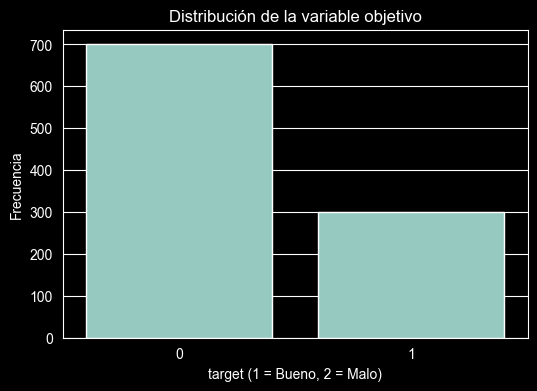

In [70]:
print("Distribución de la variable 'clase':")
print(df['clase'].value_counts())
print("\nProporción:")
print(df['clase'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6,4))
sns.countplot(x='clase', data=df)
plt.title('Distribución de la variable objetivo')
plt.xlabel('target (1 = Bueno, 2 = Malo)')
plt.ylabel('Frecuencia')
plt.show()

El dataset presenta un desbalance de target:
No es simétrico (no es 50 / 50).Existe una proporción aproximada de 70% buenos clientes vs 30% clientes de riesgo.La variable objetivo muestra un comportamiento realista del dominio crediticio, donde predominan los buenos pagadores.

## Información básica

In [51]:
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nPrimeras 5 filas:")
display(df.head())

print("\nÚltimas 5 filas:")
display(df.tail())

print("\nInformación de tipos de datos:")
print(df.info())

print("\nNombres de columnas:")
print(df.columns.tolist())

Dimensiones: 1000 filas, 21 columnas
Tamaño en memoria: 0.71 MB

Primeras 5 filas:


,status_checking,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,investment_rate,status_sex,other_debtors,...,property,age,other_installments,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1



Últimas 5 filas:


,status_checking,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,investment_rate,status_sex,other_debtors,...,property,age,other_installments,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,0
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,0
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,0
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,1
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,...,A123,27,A143,A152,1,A173,1,A191,A201,0



Información de tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   status_checking     1000 non-null   str  
 1   duration_months     1000 non-null   int64
 2   credit_history      1000 non-null   str  
 3   purpose             1000 non-null   str  
 4   credit_amount       1000 non-null   int64
 5   savings_account     1000 non-null   str  
 6   employment_since    1000 non-null   str  
 7   investment_rate     1000 non-null   int64
 8   status_sex          1000 non-null   str  
 9   other_debtors       1000 non-null   str  
 10  residence_since     1000 non-null   int64
 11  property            1000 non-null   str  
 12  age                 1000 non-null   int64
 13  other_installments  1000 non-null   str  
 14  housing             1000 non-null   str  
 15  existing_credits    1000 non-null   int64
 16  job                 10

## Estadísticas para variables numéricas


In [71]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    print("RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:")
    display(df[numeric_cols].describe())

    print("\nEstadísticas adicionales detalladas:")
    stats_df = pd.DataFrame({
        'Media': df[numeric_cols].mean(),
        'Mediana': df[numeric_cols].median(),
        'Moda': df[numeric_cols].mode().iloc[0] if not df[numeric_cols].empty else np.nan,
        'Varianza': df[numeric_cols].var(),
        'Desv_Std': df[numeric_cols].std(),
        'Asimetría': df[numeric_cols].skew(),
        'Curtosis': df[numeric_cols].kurtosis(),
        'Min': df[numeric_cols].min(),
        'Max': df[numeric_cols].max(),
        'Rango': df[numeric_cols].max() - df[numeric_cols].min()
    }).round(3)
    display(stats_df)

RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:


,duracion_meses,monto_credito,tasa_cuota,residencia_desde,edad,creditos_existentes,num_dependientes,clase
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000



Estadísticas adicionales detalladas:


,Media,Mediana,Moda,Varianza,Desv_Std,Asimetría,Curtosis,Min,Max,Rango
duracion_meses,20.903,18.0,24.0,145.415,12.059,1.094,0.920,4,72,68
monto_credito,3271.258,2319.5,1258.0,7967843.471,2822.737,1.950,4.293,250,18424,18174
tasa_cuota,2.973,3.0,4.0,1.252,1.119,-0.531,-1.210,1,4,3
residencia_desde,2.845,3.0,4.0,1.218,1.104,-0.273,-1.381,1,4,3
edad,35.546,33.0,27.0,129.401,11.375,1.021,0.596,19,75,56
creditos_existentes,1.407,1.0,1.0,0.334,0.578,1.273,1.604,1,4,3
num_dependientes,1.155,1.0,1.0,0.131,0.362,1.909,1.649,1,2,1
clase,0.300,0.0,0.0,0.210,0.458,0.874,-1.238,0,1,1


## Visualización de distribuciones para variables numéricas


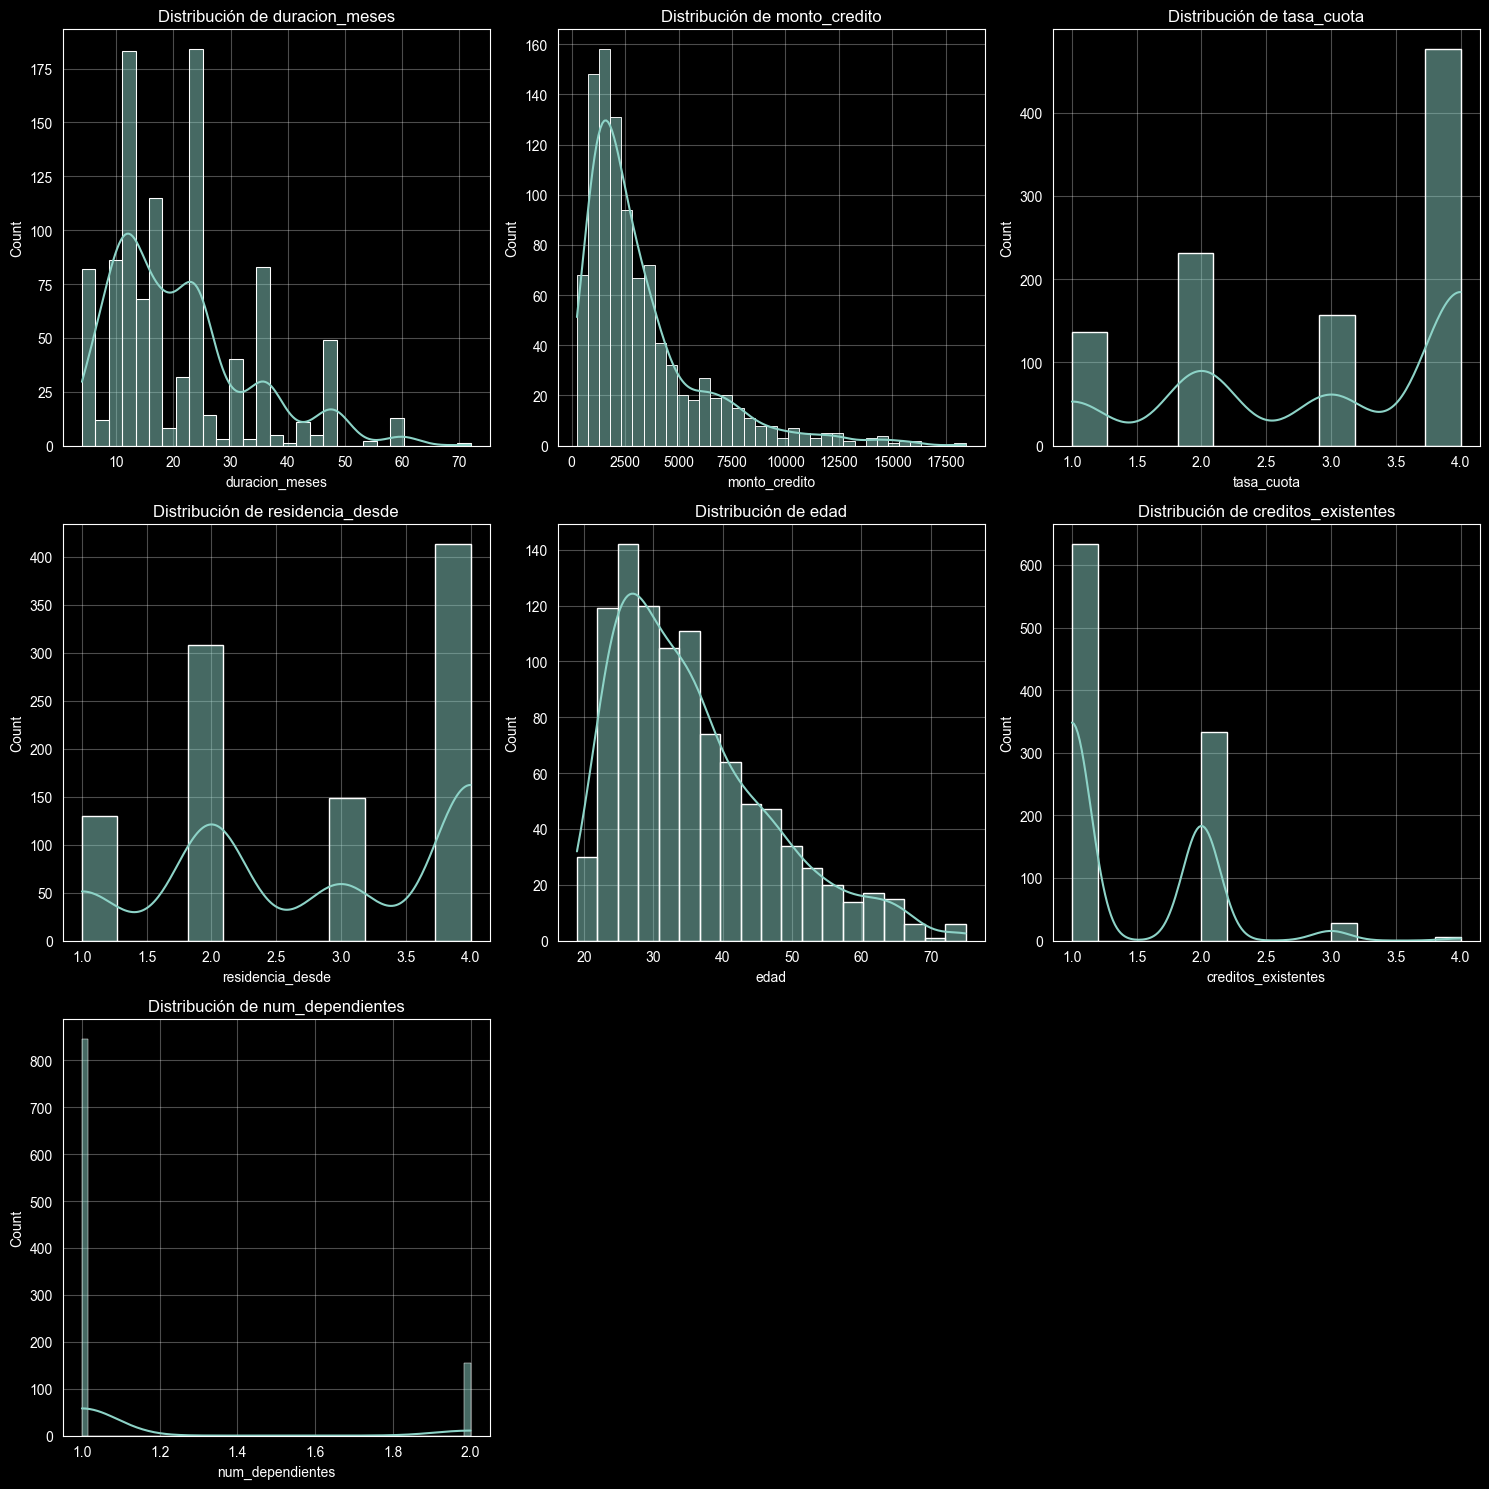

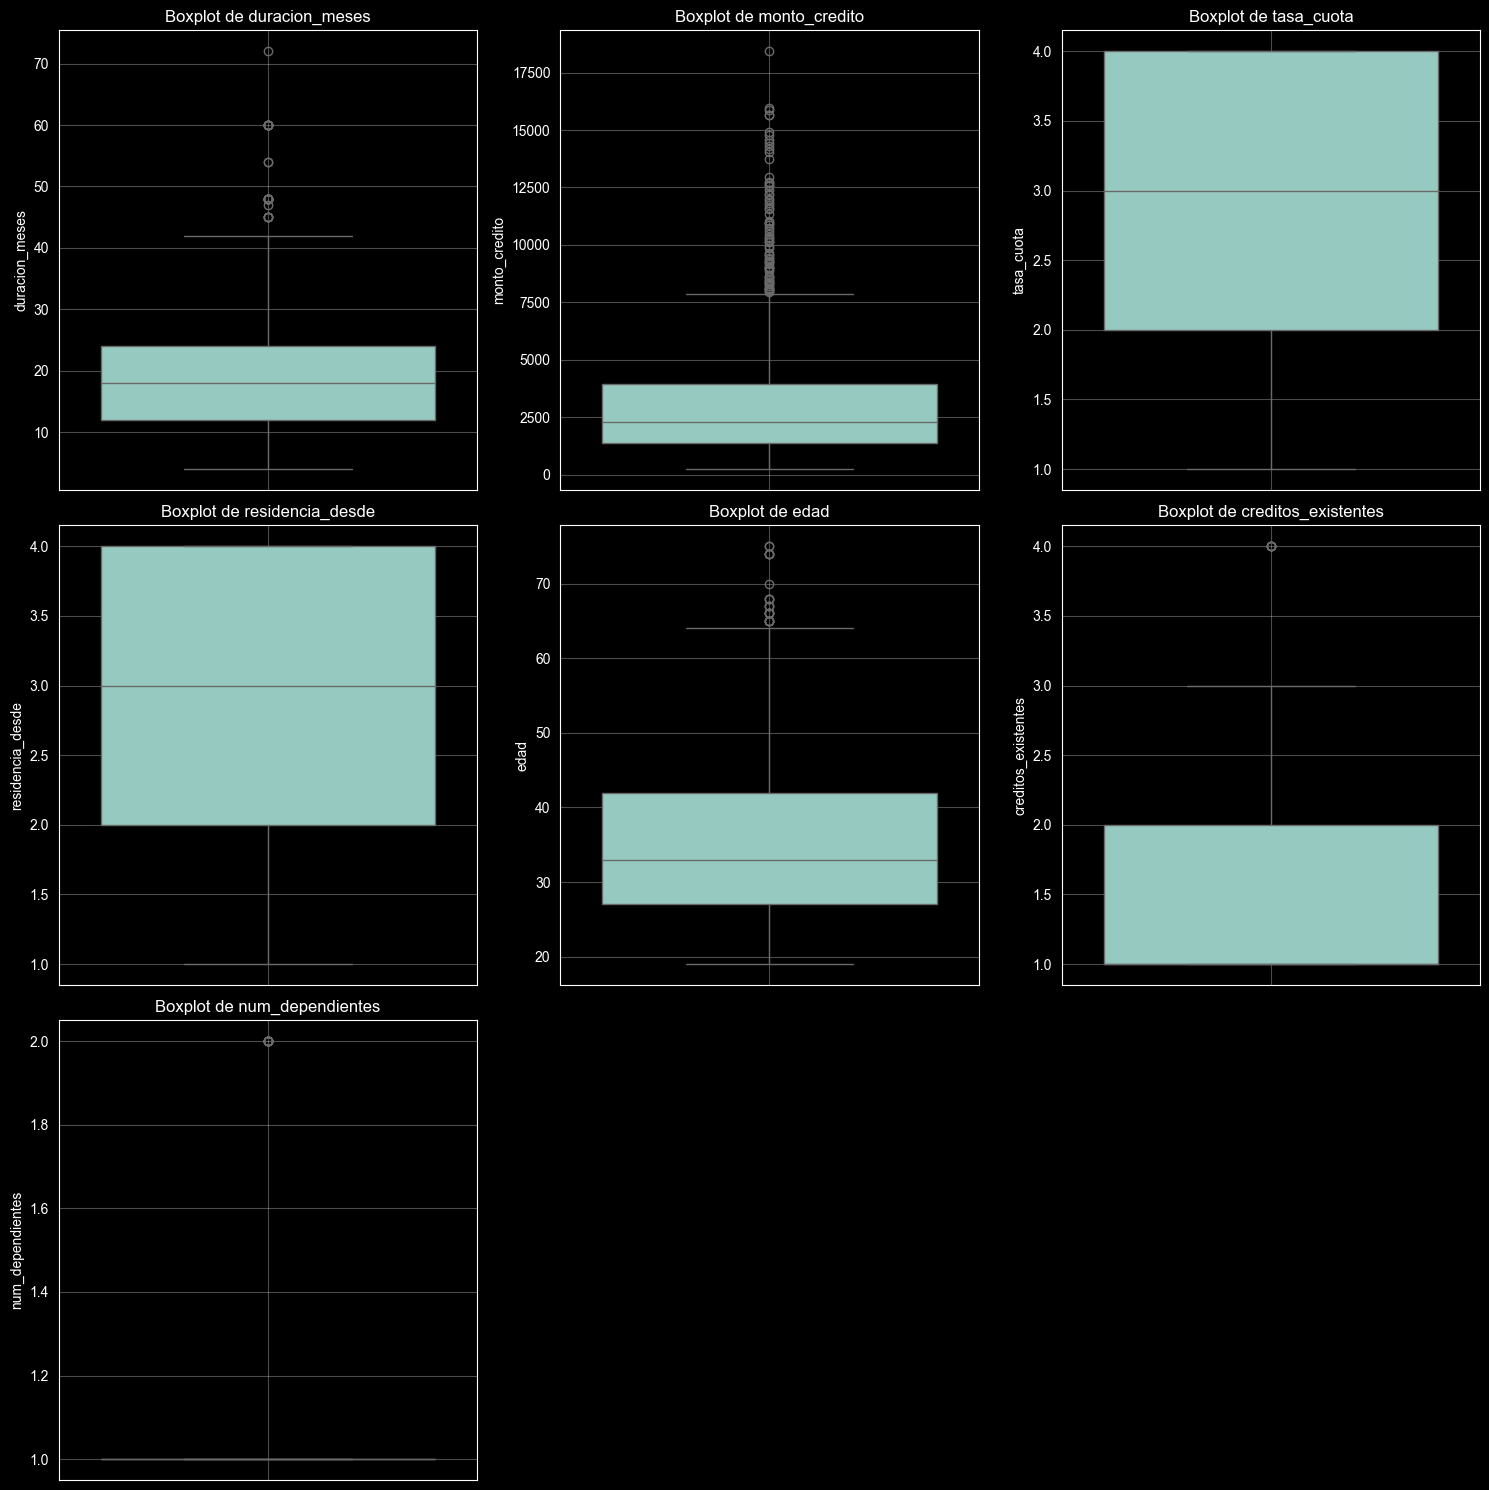

In [74]:
graph_num_cols = [col for col in numeric_cols if col != 'clase']

if len(numeric_cols) > 0:
    n_cols = min(3, len(graph_num_cols))
    n_rows = (len(graph_num_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            # Histograma con curva de densidad
            sns.histplot(data=df, x=col, kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')
            axes[i].grid(True, alpha=0.3)

    # Ocultar ejes no utilizados
    for i in range(len(numeric_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

# Boxplots para detectar outliers con las mismas columnas actualizadas
if len(numeric_cols) > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            sns.boxplot(data=df, y=col, ax=axes[i])
            axes[i].set_title(f'Boxplot de {col}')
            axes[i].grid(True, alpha=0.3)

    # Ocultar ejes no utilizados
    for i in range(len(numeric_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

duracion_meses: Aproximadamente entre 6 y 24 meses tiene mayor movimiento, esto indica que la mayoría de los créditos son de plazo corto a mediano

monto_credito: tiene una distribución muy sesgada a la derecha. La mayoría de los créditos están concentrados en montos bajos, entre 0 y 2,500, con una caída pronunciada a medida que el monto aumenta.

tasa_cuota: toma solo cuatro valores discretos (1, 2, 3, 4) que representan la tasa de cuota como porcentaje del ingreso disponible. La categoría 4 es la más frecuente.

residencia_desde: tiene cuatro valores (1 a 4) que indican los años que el cliente lleva en su residencia actual. La categoría 4 rd la más frecuente, mientras que las demas tienen menor representación. Esto sugiere que los clientes tienden a ser relativamente estables en su lugar de residencia.

edad: presenta una distribución sesgada a la derecha, con la mayor concentración de clientes entre 25 y 35 años, hay pocos clientes mayores de 60 años. Esto refleja un perfil de clientela joven-adulta, que es el segmento más activo en solicitudes de crédito.

creditos_existentes: es otra variable discreta, donde la gran mayoría de los clientes (más de 600) tiene solo 1 crédito existente, alrededor de 320 tienen 2, y muy pocos tienen 3 o 4.

num_dependientes: es binaria en la práctica, toma valores 1 o 2, con una abrumadora mayoría (más de 800), y una minoría (alrededor de 150) con 2.

## Correlaciones

Matriz de correlación lineal:


,duracion_meses,monto_credito,tasa_cuota,residencia_desde,edad,creditos_existentes,num_dependientes
duracion_meses,1.000,0.625,0.075,0.034,-0.036,-0.011,-0.024
monto_credito,0.625,1.000,-0.271,0.029,0.033,0.021,0.017
tasa_cuota,0.075,-0.271,1.000,0.049,0.058,0.022,-0.071
residencia_desde,0.034,0.029,0.049,1.000,0.266,0.090,0.043
edad,-0.036,0.033,0.058,0.266,1.000,0.149,0.118
creditos_existentes,-0.011,0.021,0.022,0.090,0.149,1.000,0.110
num_dependientes,-0.024,0.017,-0.071,0.043,0.118,0.110,1.000


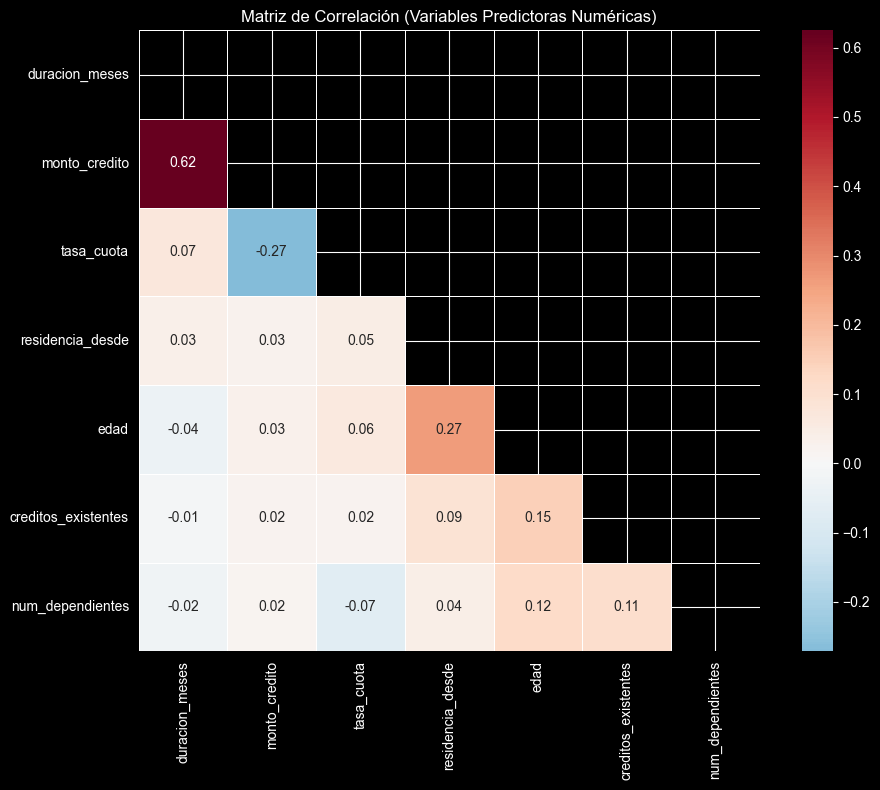

In [75]:
if len(graph_num_cols) > 1:
    correlation_matrix = df[graph_num_cols].corr()

    print("Matriz de correlación lineal:")
    display(correlation_matrix.round(3))

    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix,
                annot=True,
                cmap='RdBu_r',
                center=0,
                mask=mask,
                square=True,
                linewidths=0.5,
                fmt='.2f')

    plt.title('Matriz de Correlación (Variables Predictoras Numéricas)')
    plt.tight_layout()
    plt.show()

La correlación más fuerte es entre duration_months y credit_amount (0.62) — créditos más grandes tienden a tener plazos más largos. El resto de correlaciones son débiles (todas por debajo de 0.27)

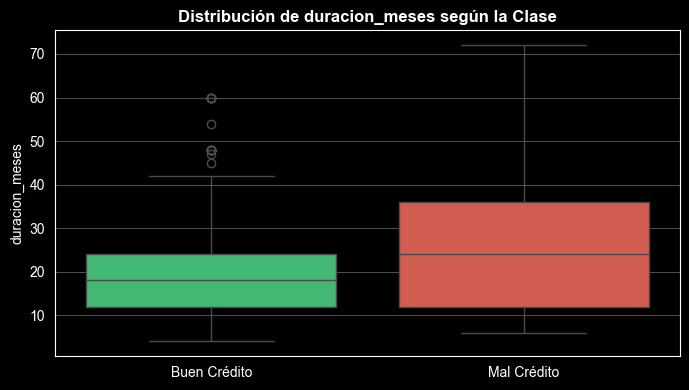

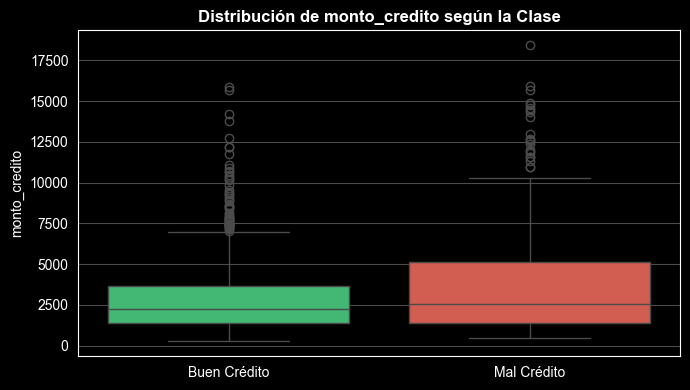

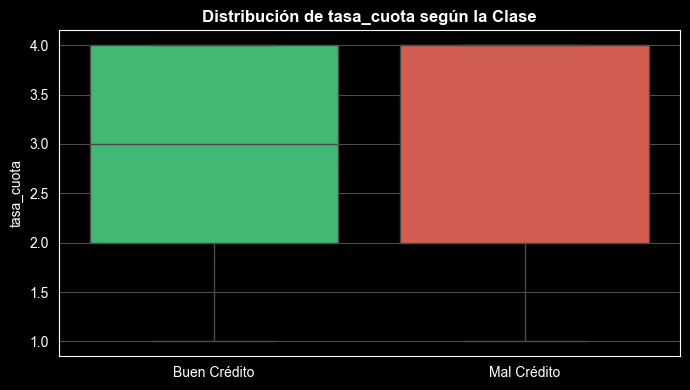

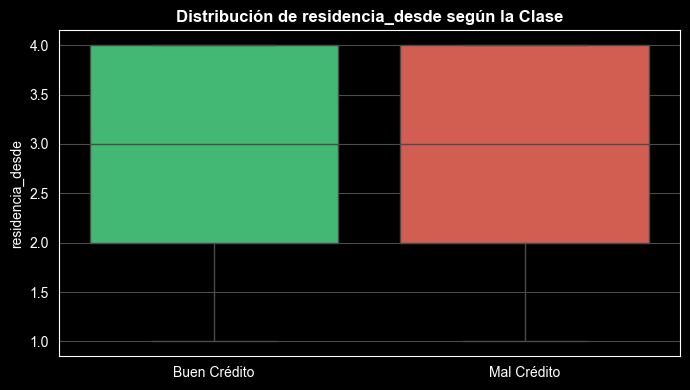

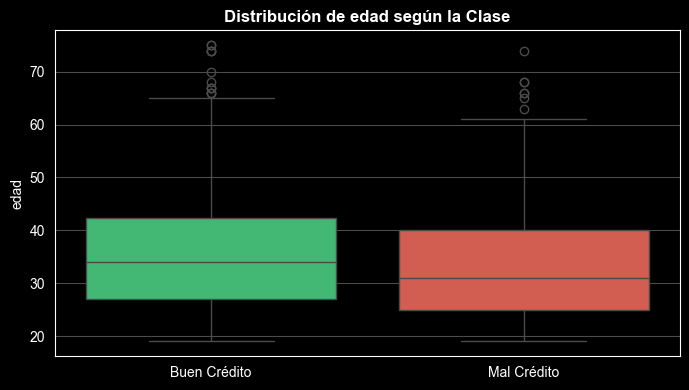

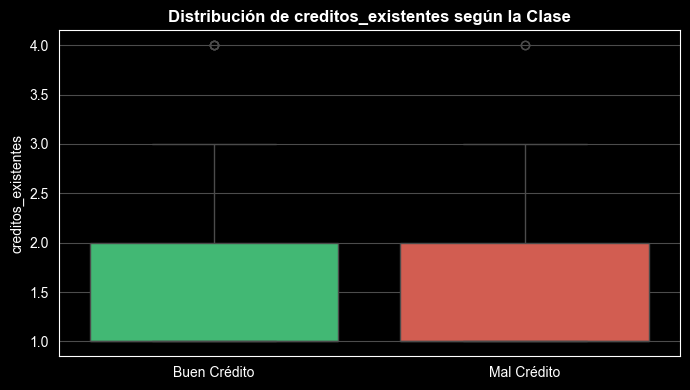

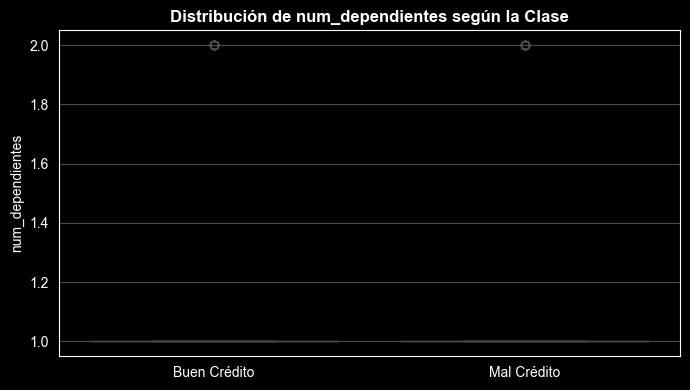

In [76]:
for num_col in graph_num_cols:
    plt.figure(figsize=(7, 4))

    sns.boxplot(data=df, x='clase', y=num_col, hue='clase',
                palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False)

    plt.xticks([0, 1], ['Buen Crédito', 'Mal Crédito'])
    plt.title(f'Distribución de {num_col} según la Clase', fontweight='bold')
    plt.xlabel('')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

Duración en Meses (duracion_meses - 7.0% Outliers):
El gráfico muestra una concentración en plazos de 12 a 24 meses. Los 70 valores atípicos representan créditos a muy largo plazo (superiores a 42 meses). Hallazgo: Existe una correlación visual entre estos valores extremos y la clasificación de "Malo", sugiriendo que el riesgo se dispara en plazos extendidos.

Monto del Crédito (monto_credito - 7.2% Outliers):
Es la variable con mayor dispersión. Los outliers identifican créditos superiores a los 7,500 DM aproximadamente. Al ser 72 registros de cuantía elevada, representan la mayor exposición financiera del banco. Acción: No deben eliminarse, ya que el modelo debe aprender a identificar el riesgo en préstamos de alto valor.

Tasa de Cuota (tasa_cuota - 0.0% Outliers):
El boxplot es compacto y no presenta valores fuera de los bigotes. Esto indica que la carga financiera respecto al ingreso de los solicitantes está estandarizada legal o institucionalmente entre el 1% y 4%, sin casos excepcionales de sobreendeudamiento declarado.

Residencia Actual (residence_desde - 0.0% Outliers):
No se detectan anomalías. La distribución es uniforme entre 1 y 4 años. Este gráfico confirma que la estabilidad domiciliaria en la muestra es consistente y no presenta casos atípicos que distorsionen la media.

Edad (edad - 2.3% Outliers):
La mayoría de los solicitantes se sitúan entre los 27 y 42 años. Los 23 outliers corresponden a clientes de edad avanzada (mayores de 64 años aproximadamente). Interpretación: Representan un segmento minoritario pero valioso para el análisis de estabilidad por madurez.

Créditos Existentes (creditos_existentes - 0.6% Outliers):
Casi la totalidad de la muestra tiene 1 o 2 créditos. Los 6 casos atípicos identifican clientes con 3 o 4 créditos activos en la misma institución, marcando un perfil de "usuario intensivo" que requiere vigilancia especial por riesgo de acumulación.

Número de Dependientes (num_dependientes - 15.5% Outliers):
El alto porcentaje de outliers no indica errores, sino que la variable es mayoritariamente binaria (1 o 2 dependientes). El outlier estadístico aquí identifica a las familias numerosas. Nota: Aunque estadísticamente son muchos, técnicamente representan una categoría minoritaria en la población del dataset.

## Target

TABLA DE FRECUENCIAS ABSOLUTAS: estado_cuenta por clase


C:\Users\johel\AppData\Local\Temp\ipykernel_3492\981409216.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


clase,0,1
estado_cuenta,,
A11,139,135
A12,164,105
A13,49,14
A14,348,46


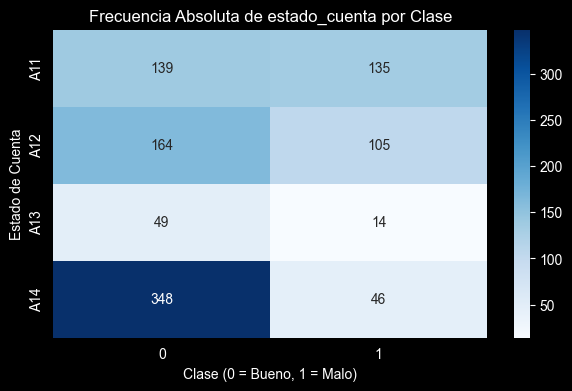


--- Tabla de Proporciones: estado_cuenta vs clase ---
clase              0      1
estado_cuenta              
A11            0.507  0.493
A12            0.610  0.390
A13            0.778  0.222
A14            0.883  0.117


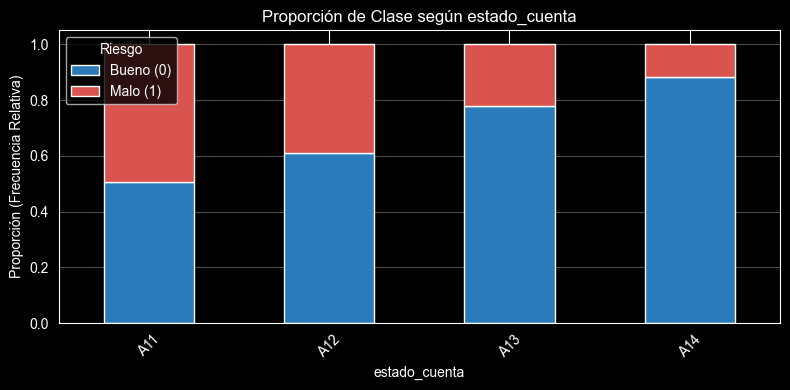


--- Tabla de Proporciones: historial_credito vs clase ---
clase                  0      1
historial_credito              
A30                0.375  0.625
A31                0.429  0.571
A32                0.681  0.319
A33                0.682  0.318
A34                0.829  0.171


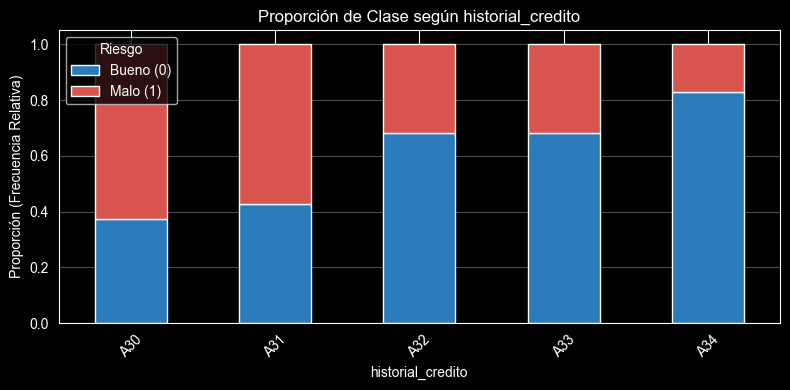


--- Tabla de Proporciones: proposito vs clase ---
clase          0      1
proposito              
A40        0.620  0.380
A41        0.835  0.165
A410       0.583  0.417
A42        0.680  0.320
A43        0.779  0.221
A44        0.667  0.333
A45        0.636  0.364
A46        0.560  0.440
A48        0.889  0.111
A49        0.649  0.351


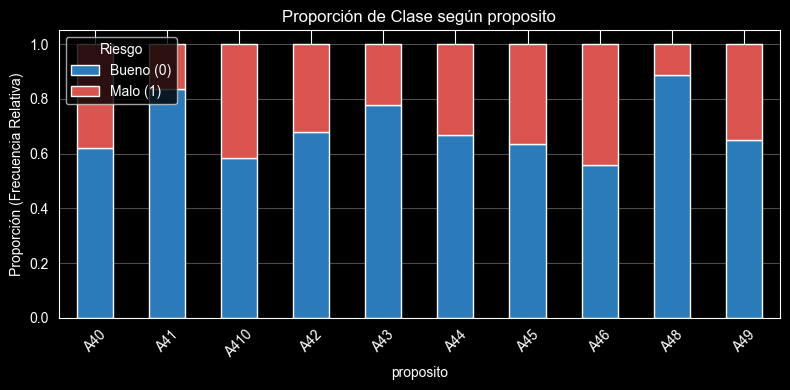


--- Tabla de Proporciones: estado_ahorros vs clase ---
clase               0      1
estado_ahorros              
A61             0.640  0.360
A62             0.670  0.330
A63             0.825  0.175
A64             0.875  0.125
A65             0.825  0.175


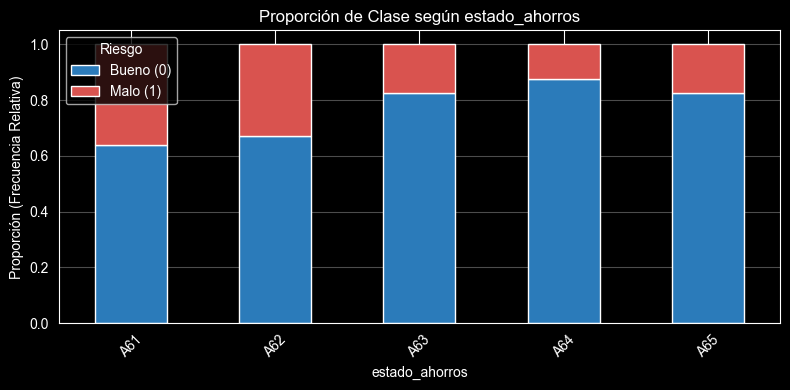


--- Tabla de Proporciones: empleo_anyos vs clase ---
clase             0      1
empleo_anyos              
A71           0.629  0.371
A72           0.593  0.407
A73           0.693  0.307
A74           0.776  0.224
A75           0.747  0.253


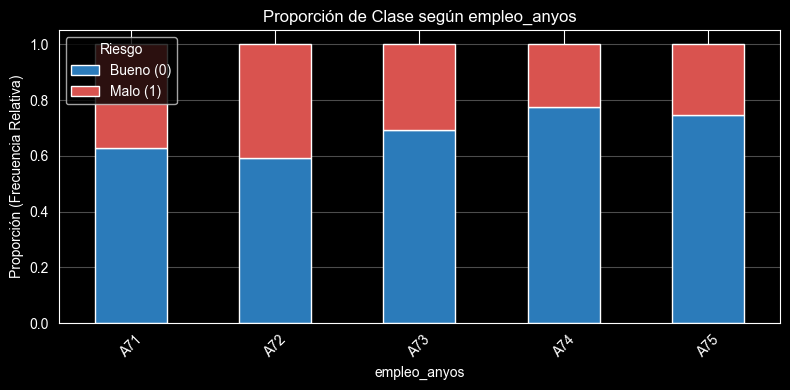


--- Tabla de Proporciones: estado_personal vs clase ---
clase                0      1
estado_personal              
A91              0.600  0.400
A92              0.648  0.352
A93              0.734  0.266
A94              0.728  0.272


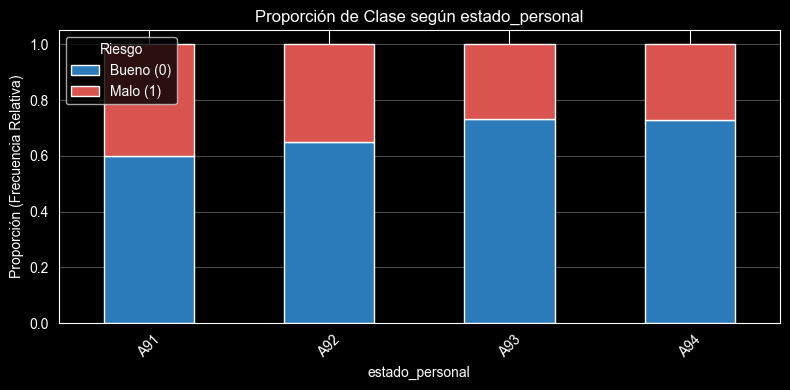


--- Tabla de Proporciones: otros_deudores vs clase ---
clase               0      1
otros_deudores              
A101            0.700  0.300
A102            0.561  0.439
A103            0.808  0.192


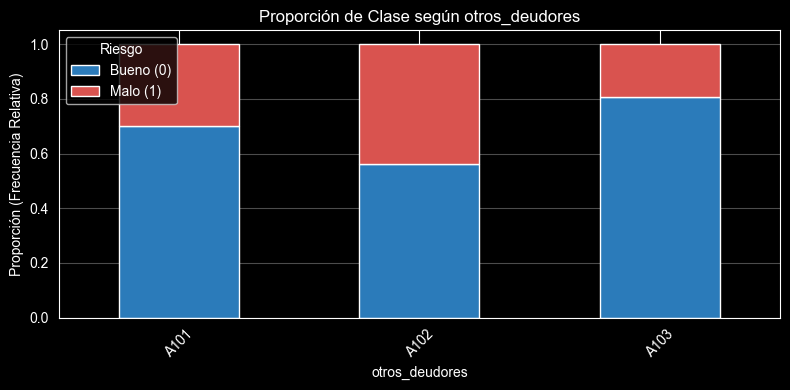


--- Tabla de Proporciones: tipo_propiedad vs clase ---
clase               0      1
tipo_propiedad              
A121            0.787  0.213
A122            0.694  0.306
A123            0.693  0.307
A124            0.565  0.435


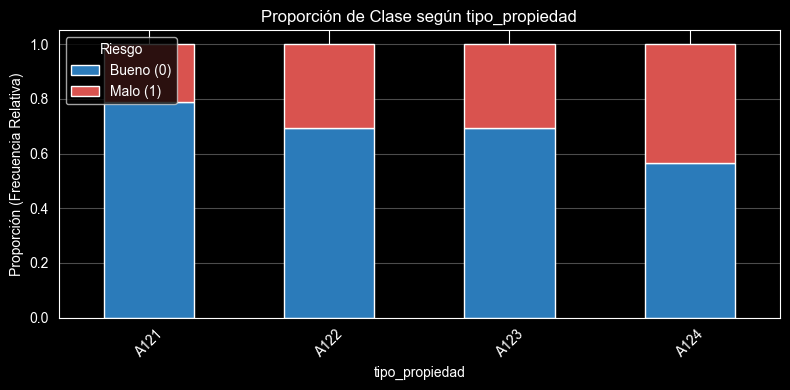


--- Tabla de Proporciones: otros_planes_pago vs clase ---
clase                  0      1
otros_planes_pago              
A141               0.590  0.410
A142               0.596  0.404
A143               0.725  0.275


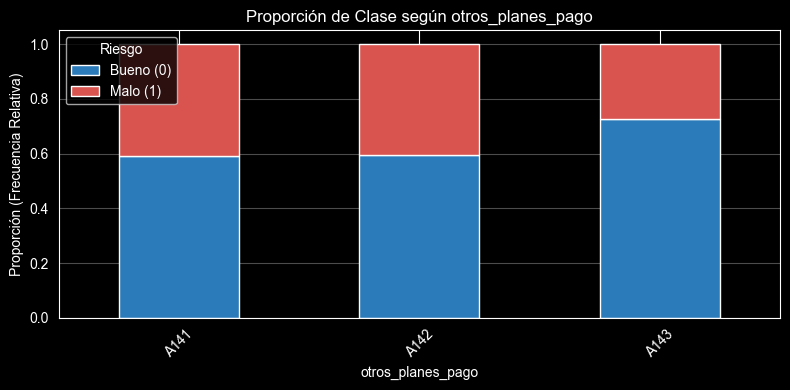


--- Tabla de Proporciones: vivienda vs clase ---
clase         0      1
vivienda              
A151      0.609  0.391
A152      0.739  0.261
A153      0.593  0.407


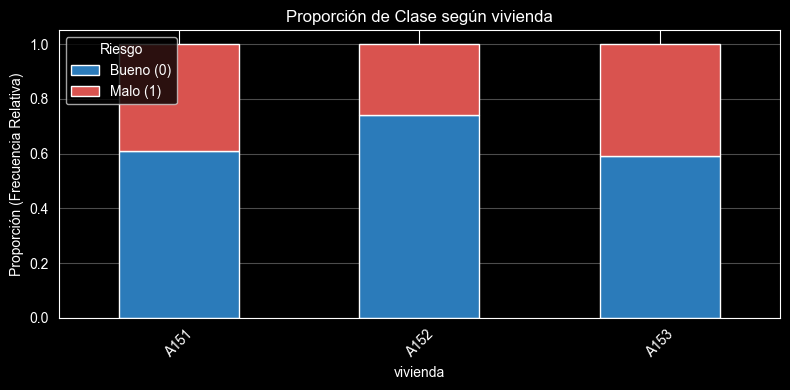


--- Tabla de Proporciones: tipo_empleo vs clase ---
clase            0      1
tipo_empleo              
A171         0.682  0.318
A172         0.720  0.280
A173         0.705  0.295
A174         0.655  0.345


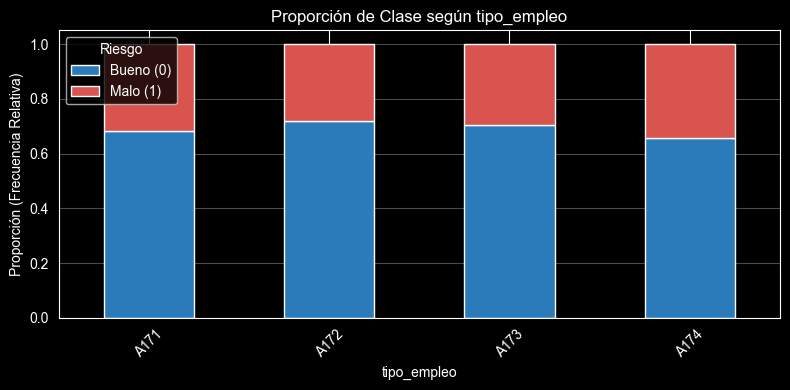


--- Tabla de Proporciones: telefono_propio vs clase ---
clase                0      1
telefono_propio              
A191             0.686  0.314
A192             0.720  0.280


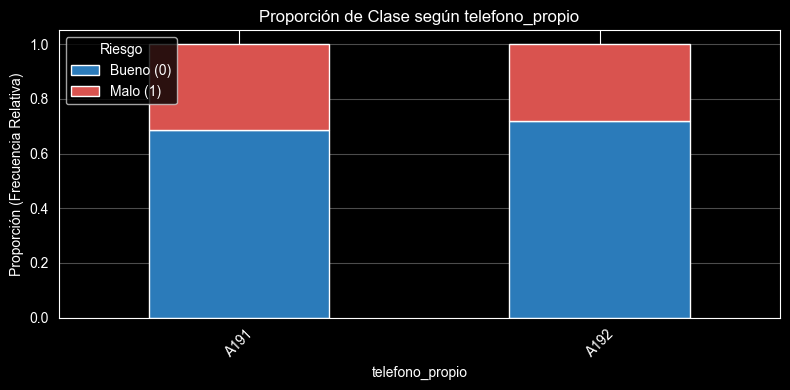


--- Tabla de Proporciones: trabajador_extranjero vs clase ---
clase                      0      1
trabajador_extranjero              
A201                   0.693  0.307
A202                   0.892  0.108


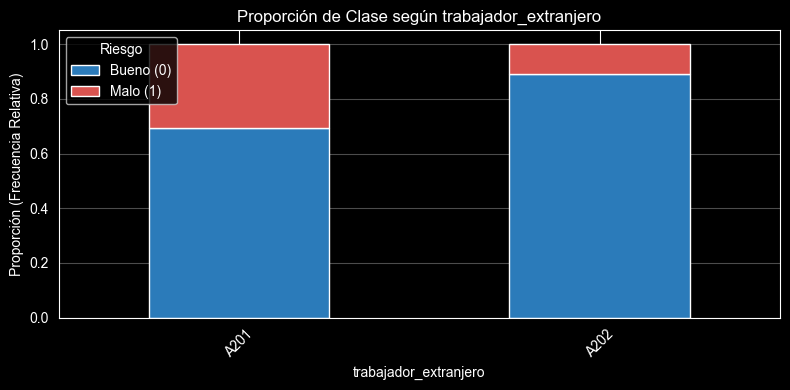

In [77]:
# Identificamos las variables categóricas reales presentes
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Frecuencia inicial específica solicitada para el estado de cuenta
if 'estado_cuenta' in df.columns:
    print("TABLA DE FRECUENCIAS ABSOLUTAS: estado_cuenta por clase")
    crosstab_cuenta = pd.crosstab(df['estado_cuenta'], df['clase'])
    display(crosstab_cuenta)

    plt.figure(figsize=(7, 4))
    sns.heatmap(crosstab_cuenta, annot=True, fmt='d', cmap='Blues')
    plt.title('Frecuencia Absoluta de estado_cuenta por Clase')
    plt.ylabel('Estado de Cuenta')
    plt.xlabel('Clase (0 = Bueno, 1 = Malo)')
    plt.show()

# Iteración general de comportamiento para todas las categóricas
for col in categorical_cols:
    print(f"\n--- Tabla de Proporciones: {col} vs clase ---")
    crosstab_rel = pd.crosstab(df[col], df['clase'], normalize='index')
    print(crosstab_rel.round(3))

    crosstab_rel.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#2b7bba', '#d9534f'])
    plt.title(f'Proporción de Clase según {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción (Frecuencia Relativa)')
    plt.legend(title='Riesgo', labels=['Bueno (0)', 'Malo (1)'], loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [78]:
print("ESTADÍSTICOS DESCRIPTIVOS COMPLETO SEGMENTADOS POR CLASE (TARGET):")
display(df.groupby('clase')[graph_num_cols].describe().transpose())

ESTADÍSTICOS DESCRIPTIVOS COMPLETO SEGMENTADOS POR CLASE (TARGET):


clase                                 0             1
duracion_meses      count    700.000000    300.000000
                    mean      19.207143     24.860000
                    std       11.079564     13.282639
                    min        4.000000      6.000000
                    25%       12.000000     12.000000
                    50%       18.000000     24.000000
                    75%       24.000000     36.000000
                    max       60.000000     72.000000
monto_credito       count    700.000000    300.000000
                    mean    2985.457143   3938.126667
                    std     2401.472278   3535.818955
                    min      250.000000    433.000000
                    25%     1375.500000   1352.500000
                    50%     2244.000000   2574.500000
                    75%     3634.750000   5141.500000
                    max    15857.000000  18424.000000
tasa_cuota          count    700.000000    300.000000
                    mean       2.920000      3.096667
                    std        1.128078      1.088395
                    min        1.000000      1.000000
                    25%        2.000000      2.000000
                    50%        3.000000      4.000000
                    75%        4.000000      4.000000
                    max        4.000000      4.000000
residencia_desde    count    700.000000    300.000000
                    mean       2.842857      2.850000
                    std        1.108373      1.094605
                    min        1.000000      1.000000
                    25%        2.000000      2.000000
                    50%        3.000000      3.000000
                    75%        4.000000      4.000000
                    max        4.000000      4.000000
edad                count    700.000000    300.000000
                    mean      36.224286     33.963333
                    std       11.381145     11.222379
                    min       19.000000     19.000000
                    25%       27.000000     25.000000
                    50%       34.000000     31.000000
                    75%       42.250000     40.000000
                    max       75.000000     74.000000
creditos_existentes count    700.000000    300.000000
                    mean       1.424286      1.366667
                    std        0.584721      0.559702
                    min        1.000000      1.000000
                    25%        1.000000      1.000000
                    50%        1.000000      1.000000
                    75%        2.000000      2.000000
                    max        4.000000      4.000000
num_dependientes    count    700.000000    300.000000
                    mean       1.155714      1.153333
                    std        0.362844      0.360911
                    min        1.000000      1.000000
                    25%        1.000000      1.000000
                    50%        1.000000      1.000000
                    75%        1.000000      1.000000
                    max        2.000000      2.000000